<a href="https://colab.research.google.com/github/SuhaniGupta99/Crop_yield_prediction/blob/main/Crop_yield_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Imports & Setup
import pandas as pd
import numpy as np
from google.colab import files

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42


In [ ]:
#@title Upload + Load Dataset
from google.colab import files
uploaded = files.upload()
data = pd.read_csv("Crop_production.csv.zip", na_values="=")

Saving Crop_production.csv.zip to Crop_production.csv.zip


In [ ]:
#@title Remove data leakage columns
leakage_cols = ['Production_in_tons', 'Area_in_hectares']
data = data.drop(columns=leakage_cols, errors='ignore')
print("✅ Removed potential leakage columns:", leakage_cols)

✅ Removed potential leakage columns: ['Production_in_tons', 'Area_in_hectares']


In [ ]:
data.isna().sum()

,0
Unnamed: 0,0
State_Name,0
Crop_Type,0
Crop,0
N,0
P,0
K,0
pH,0
rainfall,0
temperature,0


In [ ]:
#@title Check for Duplicate Rows
duplicates_count = data.duplicated().sum()
print(f"🔍 Number of duplicate rows in dataset: {duplicates_count}")

🔍 Number of duplicate rows in dataset: 0


In [ ]:
#@title Step 6: Feature Engineering
import numpy as np

def add_engineered_features(data_in):
    data = data_in.copy()

    # Ensure all required columns exist
    for col in ["N", "P", "K", "pH", "rainfall", "temperature"]:
        if col not in data.columns:
            data[col] = np.nan

    # New engineered features
    data["NPK_mean"] = (data["N"] + data["P"] + data["K"]) / 3
    data["N_P_ratio"] = data["N"] / (data["P"] + 1e-6)
    data["rain_temp_interaction"] = data["rainfall"] * data["temperature"]
    data["rainfall_per_degree"] = data["rainfall"] / (data["temperature"] + 1e-6)

    return data

# Apply the feature engineering function
data = add_engineered_features(data)

print("Feature engineering complete. New columns added:")
print(["NPK_mean", "N_P_ratio", "rain_temp_interaction", "rainfall_per_degree"])


✅ Feature engineering complete. New columns added:
['NPK_mean', 'N_P_ratio', 'rain_temp_interaction', 'rainfall_per_degree']


In [ ]:
#@title Step: Remove Outliers (IQR Method)

def remove_outliers_iqr(df_in, factor=1.5):
    """
    Removes outliers from all numeric columns using the IQR method.
    factor=1.5 means points outside 1.5*IQR are removed.
    """
    df = df_in.copy()
    numeric_cols = df.select_dtypes(include=['number']).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        before = len(df)
        df = df[(df[col] >= lower) & (df[col] <= upper)]
        after = len(df)
        removed = before - after
        if removed > 0:
            print(f"Removed {removed} outliers from '{col}'")

    print(f"Final dataset shape after outlier removal: {df.shape}")
    return df

data = remove_outliers_iqr(data, factor=1.5)


⚠️ Removed 5441 outliers from 'N'
⚠️ Removed 42875 outliers from 'P'
⚠️ Removed 1438 outliers from 'K'
⚠️ Removed 4306 outliers from 'pH'
⚠️ Removed 428 outliers from 'rainfall'
⚠️ Removed 643 outliers from 'temperature'
⚠️ Removed 1814 outliers from 'Yield_ton_per_hec'
⚠️ Removed 153 outliers from 'rainfall_per_degree'
✅ Final dataset shape after outlier removal: (42751, 15)


In [ ]:
#@title Step: Log Transform the Target Variable

import numpy as np

# Apply log1p transform (handles zeros safely)
y = np.log1p(data["Yield_ton_per_hec"])

# Define features (make sure target column not in X)
X = data.drop(columns=["Yield_ton_per_hec"])

print("Applied log transform to target variable (Yield_ton_per_hec).")


✅ Applied log transform to target variable (Yield_ton_per_hec).


In [ ]:
#@title Define features and target
X = data.drop(columns=['Yield_ton_per_hec'])
y = data['Yield_ton_per_hec']

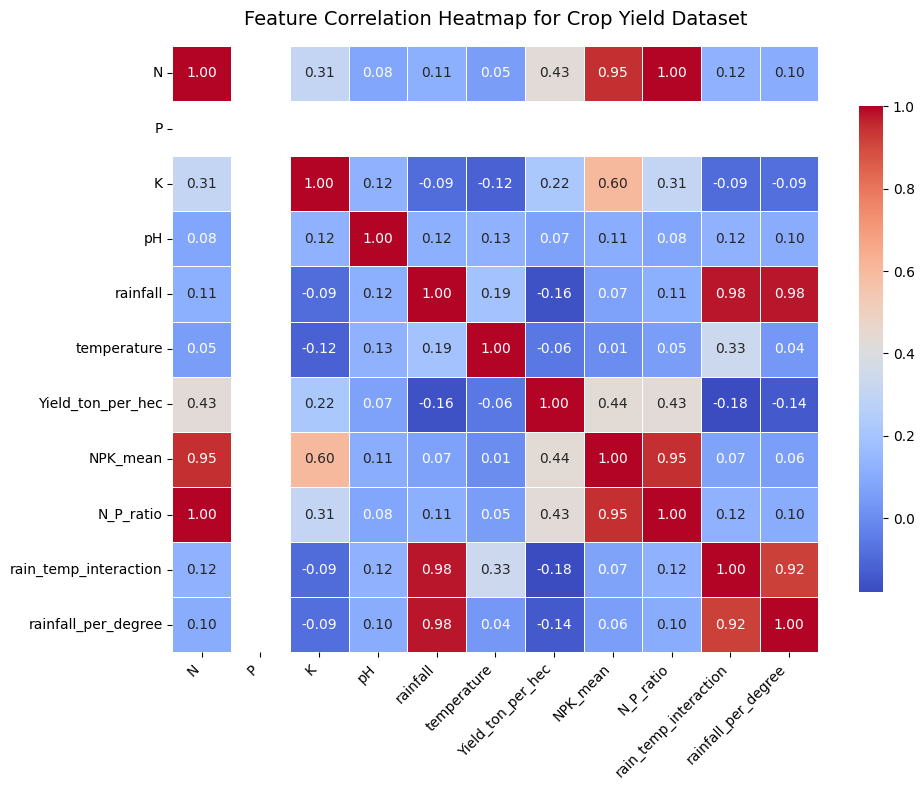

In [ ]:
# Correlation Analysis (Heatmap)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  Remove unnamed or irrelevant columns
data_cleaned = data.loc[:, ~data.columns.str.contains('^Unnamed')]

# Select only numeric columns
numeric_df = data_cleaned.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,           # Display correlation values
    fmt=".2f",            # Two decimal places
    cmap="coolwarm",      # Color scheme
    linewidths=0.5,       # Line spacing between cells
    cbar_kws={"shrink": 0.8}  # Smaller color bar
)

# Title and formatting
plt.title("Feature Correlation Heatmap for Crop Yield Dataset", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
#@title Label Encoding

from sklearn.preprocessing import LabelEncoder

def label_encode_train_test(X_train, X_test):
    """
    Fits label encoders on training data only,
    and applies same mappings to test data.
    """
    X_train = X_train.copy()
    X_test = X_test.copy()
    label_encoders = {}

    for col in X_train.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col])
        # Handle unseen categories in test set
        X_test[col] = X_test[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)
        label_encoders[col] = le

    print("Label encoding applied safely on:", list(label_encoders.keys()))
    return X_train, X_test, label_encoders


In [ ]:
#@title Robust Stratified Split
from sklearn.model_selection import train_test_split

stratify_col = "Crop"  # or "Crop_Type"

# 1️ Ensure no missing values in the stratification column
data[stratify_col] = data[stratify_col].fillna("Unknown")

# 2️ Group rare categories into 'Other' (with >= 2 samples)
min_samples = 2
data["Crop_grouped"] = data[stratify_col].where(
    data[stratify_col].map(data[stratify_col].value_counts()) >= min_samples, "Other"
)

# 3️ Double-check that stratification is valid
# If any category still has only 1 sample → fallback to random split
if data["Crop_grouped"].value_counts().min() < 2:
    print(" Some categories still too small for stratification. Using random split instead.")
    stratify_param = None
else:
    stratify_param = data["Crop_grouped"]

# 4️ Perform the split safely
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_param
)

print("Safe stratified split complete (auto-handles rare crops).")
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# 5️ Encode categorical columns AFTER split
X_train, X_test, label_encoders = label_encode_train_test(X_train, X_test)
print("Categorical encoding applied safely.")


✅ Safe stratified split complete (auto-handles rare crops).
Train size: 34200, Test size: 8551
✅ Label encoding applied safely on: ['State_Name', 'Crop_Type', 'Crop']
✅ Categorical encoding applied safely.


In [ ]:
#@title Initialize models
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

}

In [ ]:
#@title Train and evaluate models
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2_Score": r2
    })

In [ ]:
#@title Show comparison results
results_df = pd.DataFrame(results)
print("Model Comparison Results:")
print(results_df.sort_values(by="MAE"))

Model Comparison Results:
               Model       MAE      RMSE  R2_Score
2      Random Forest  0.335157  0.494391  0.698803
1  Gradient Boosting  0.425398  0.569855  0.599834
0      Decision Tree  0.426775  0.639060  0.496738


In [ ]:
#@title Calculate and Display Relative MAE for Each Model

# Compute mean yield
mean_yield = y_test.mean()

# Add relative MAE column
results_df["Relative_MAE (%)"] = (results_df["MAE"] / mean_yield) * 100

# Detect correct R² column name (handles R2 or R2_Score)
r2_col = "R2" if "R2" in results_df.columns else "R2_Score" if "R2_Score" in results_df.columns else None

# Print updated results
cols_to_show = ["Model", "MAE", "Relative_MAE (%)"]
if r2_col:
    cols_to_show.append(r2_col)

print("🌾 Model Performance with Relative MAE:")
print(results_df[cols_to_show].sort_values(by="MAE"))

# Interpret performance
for _, row in results_df.iterrows():
    rel_mae = row["Relative_MAE (%)"]
    if rel_mae <= 10:
        comment = " Excellent"
    elif rel_mae <= 15:
        comment = " Good"
    elif rel_mae <= 25:
        comment = " Acceptable"
    else:
        comment = "Needs Improvement"
    print(f"{row['Model']}: {rel_mae:.2f}% → {comment}")


🌾 Model Performance with Relative MAE:
               Model       MAE  Relative_MAE (%)  R2_Score
2      Random Forest  0.335157         24.375436  0.698803
1  Gradient Boosting  0.425398         30.938573  0.599834
0      Decision Tree  0.426775         31.038701  0.496738
Decision Tree: 31.04% → ⚠️ Needs Improvement
Gradient Boosting: 30.94% → ⚠️ Needs Improvement
Random Forest: 24.38% → ⚖️ Acceptable


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve



📌 Generating plots for: Decision Tree


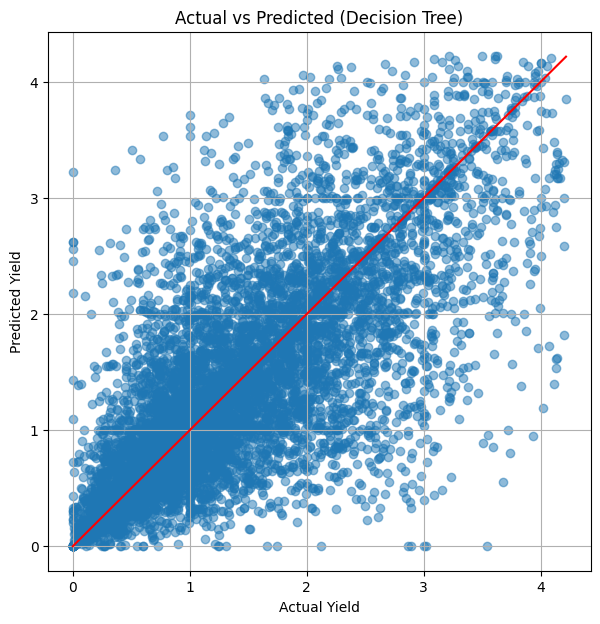

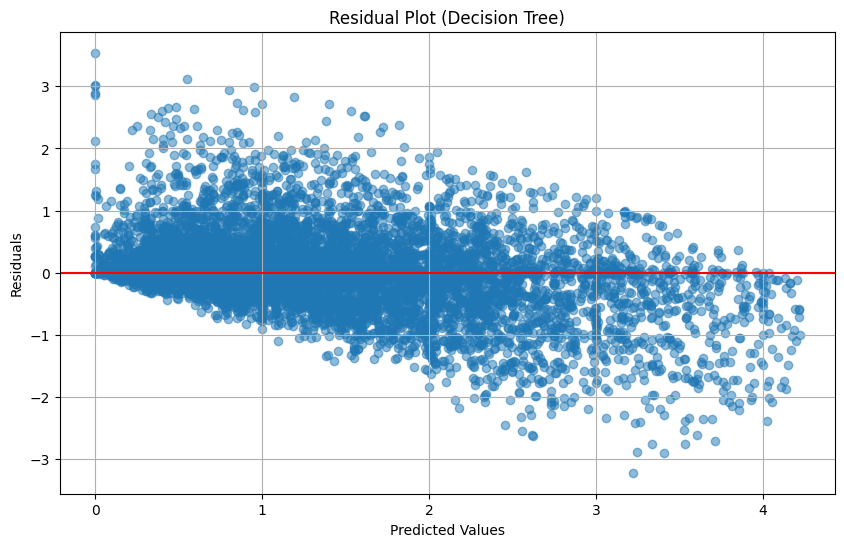

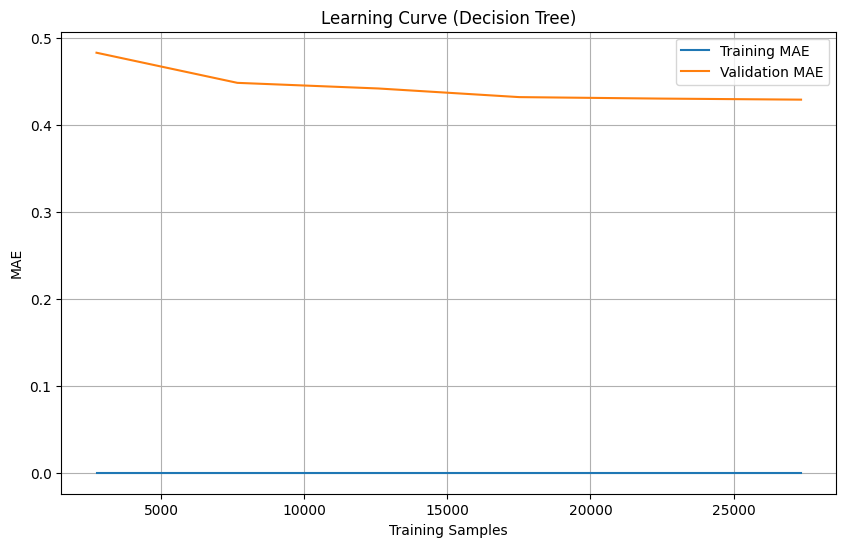


📌 Generating plots for: Gradient Boosting


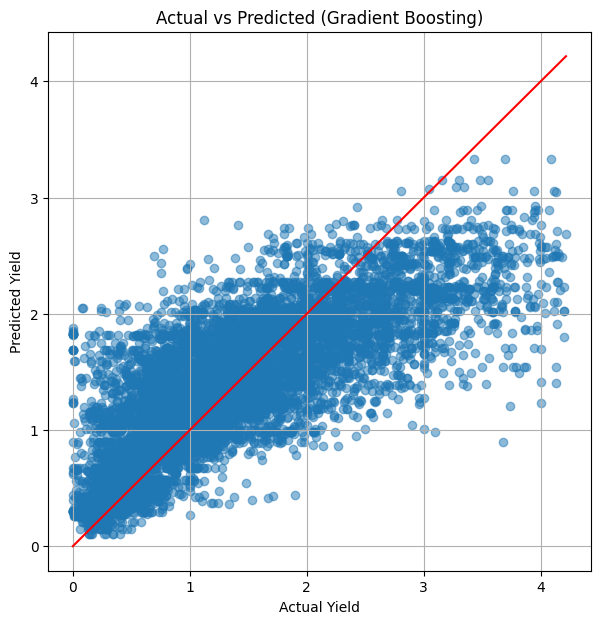

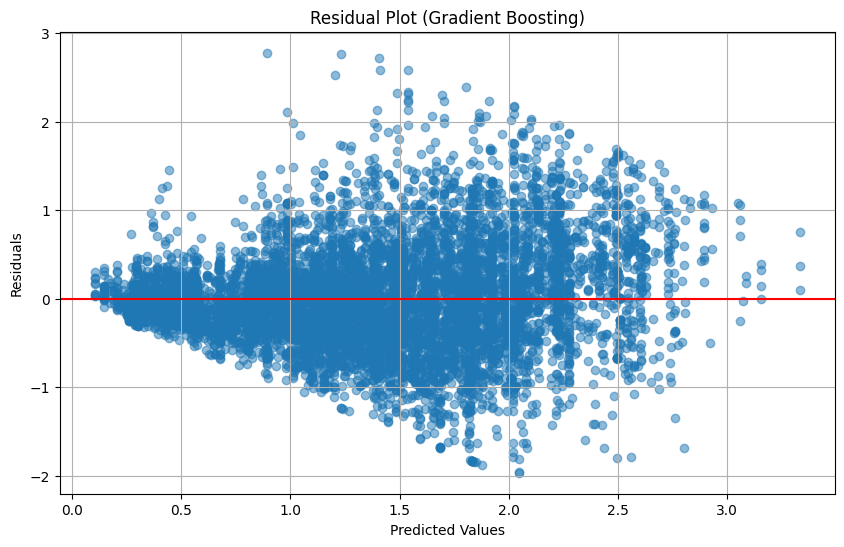

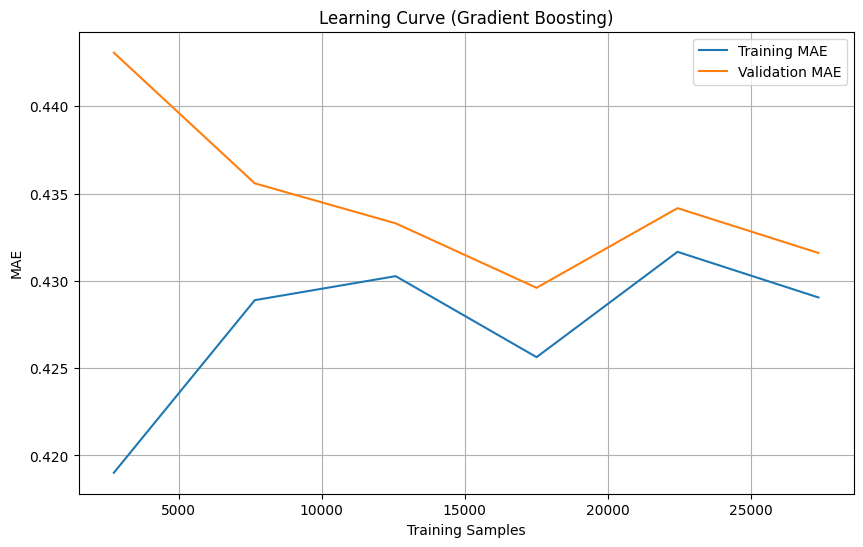


📌 Generating plots for: Random Forest


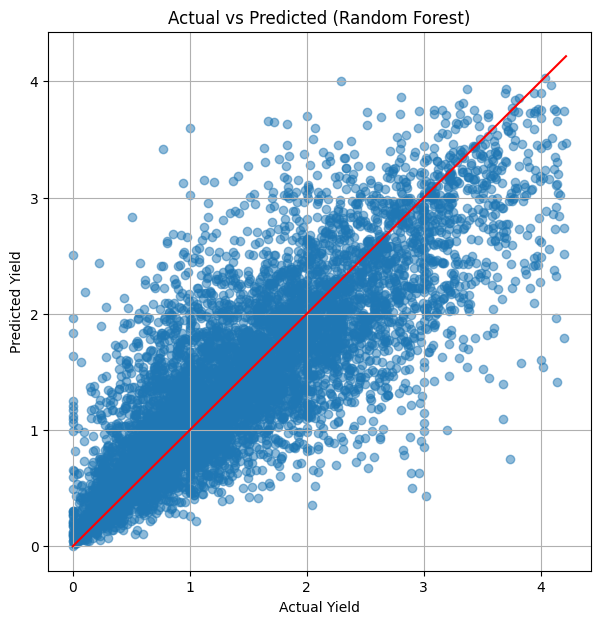

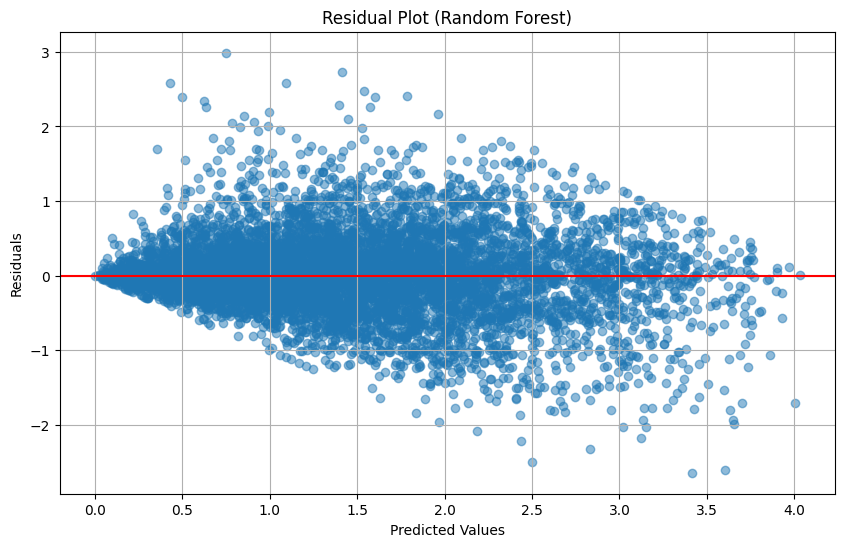

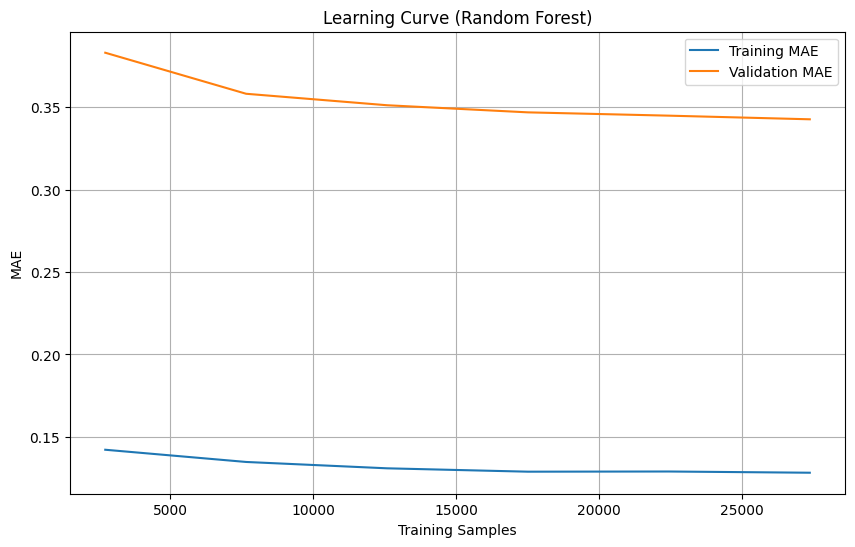

In [ ]:
#@title GENERATE PLOTS FOR ALL MODELS

for name, model in models.items():
    print(f"\n============================")
    print(f"📌 Generating plots for: {name}")
    print(f"============================")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # 1️. ACTUAL vs PREDICTED
    plt.figure(figsize=(7,7))
    plt.scatter(y_test, preds, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r')
    plt.xlabel("Actual Yield")
    plt.ylabel("Predicted Yield")
    plt.title(f"Actual vs Predicted ({name})")
    plt.grid(True)
    plt.show()


    # 2️. RESIDUAL PLOT
    residuals = y_test - preds

    plt.figure(figsize=(10,6))
    plt.scatter(preds, residuals, alpha=0.5)
    plt.axhline(0, color='red')
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot ({name})")
    plt.grid(True)
    plt.show()


    # 3️. LEARNING CURVE
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X_train, y_train,
        cv=5,
        scoring="neg_mean_absolute_error",
        train_sizes=np.linspace(0.1, 1.0, 6),
        n_jobs=-1
    )

    train_scores_mean = -train_scores.mean(axis=1)
    test_scores_mean = -test_scores.mean(axis=1)
    plt.figure(figsize=(10,6))
    plt.plot(train_sizes, train_scores_mean, label="Training MAE")
    plt.plot(train_sizes, test_scores_mean, label="Validation MAE")
    plt.xlabel("Training Samples")
    plt.ylabel("MAE")
    plt.title(f"Learning Curve ({name})")
    plt.legend()
    plt.grid(True)
    plt.show()
